In [47]:
import os
import numpy as np
import torch
from pathlib import Path
from PIL import Image

In [3]:
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt

# --------------------------------------------------
# Project path
# --------------------------------------------------

PROJECT_ROOT = Path(
    r"X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Clear cached VisionInspect imports
for name in list(sys.modules):
    if name == "src" or name.startswith("src."):
        del sys.modules[name]

# --------------------------------------------------
# VisionInspect imports
# --------------------------------------------------

from src.models.autoencoder import Autoencoder
from src.data.preprocessing import get_train_transform
from src.detection.anomaly_score import reconstruction_loss
from src.detection.heatmap import compute_anomaly_map

# --------------------------------------------------
# Device
# --------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("VisionInspect setup complete.")
print("Project:", PROJECT_ROOT)
print("Python device:", device)

VisionInspect setup complete.
Project: X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect
Python device: cuda


In [4]:
# --------------------------------------------------
# Load trained bottle autoencoder
# --------------------------------------------------

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "bottle"
    / "autoencoder.pth"
)

model = Autoencoder().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Trained bottle model loaded successfully.")
print("Model:", MODEL_PATH)

Trained bottle model loaded successfully.
Model: X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\models\bottle\autoencoder.pth


In [5]:
from PIL import Image

# --------------------------------------------------
# Select test image
# --------------------------------------------------

TEST_IMAGE_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "mvtec_anomaly_detection"
    / "bottle"
    / "test"
    / "broken_large"
    / "000.png"
)

image = Image.open(TEST_IMAGE_PATH).convert("RGB")

print("Test image:")
print(TEST_IMAGE_PATH)

print("Image size:", image.size)
print("Image mode:", image.mode)

Test image:
X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\dataset\mvtec_anomaly_detection\bottle\test\broken_large\000.png
Image size: (900, 900)
Image mode: RGB


In [6]:
# --------------------------------------------------
# Preprocess test image
# --------------------------------------------------

transform = get_train_transform()

image_tensor = transform(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# Move to GPU
image_tensor = image_tensor.to(device)

print("Tensor shape:", image_tensor.shape)
print("Device:", image_tensor.device)

Tensor shape: torch.Size([1, 3, 256, 256])
Device: cuda:0


In [7]:
# --------------------------------------------------
# Reconstruct test image
# --------------------------------------------------

with torch.no_grad():
    reconstructed = model(image_tensor)

print("Reconstruction complete.")
print("Input shape:", image_tensor.shape)
print("Output shape:", reconstructed.shape)

Reconstruction complete.
Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 3, 256, 256])


In [8]:
# --------------------------------------------------
# Calculate reconstruction error
# --------------------------------------------------

anomaly_score = reconstruction_loss(
    image_tensor,
    reconstructed
)

print("Anomaly score:", anomaly_score.item())

Anomaly score: 0.003622867865487933


In [9]:
# --------------------------------------------------
# Create pixel-level anomaly map
# --------------------------------------------------

anomaly_map = compute_anomaly_map(
    image_tensor,
    reconstructed
)

print("Anomaly map created.")
print("Shape:", anomaly_map.shape)
print("Minimum:", anomaly_map.min().item())
print("Maximum:", anomaly_map.max().item())

Anomaly map created.
Shape: torch.Size([1, 256, 256])
Minimum: 5.2412353397812694e-05
Maximum: 0.5357850193977356


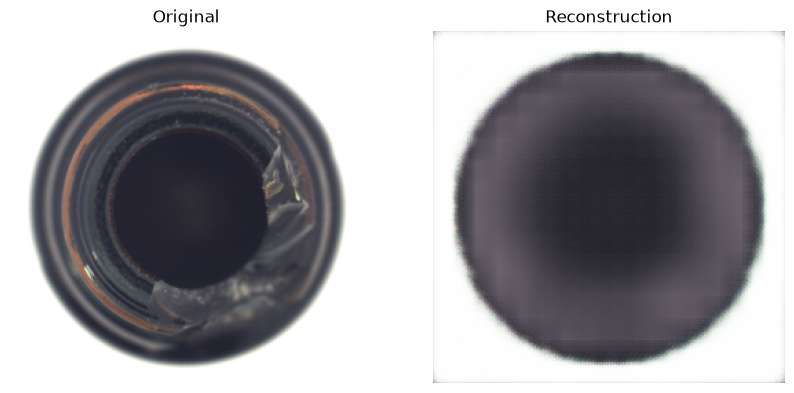

In [15]:
# --------------------------------------------------
# Visualize original and reconstruction
# --------------------------------------------------

original_display = (
    image_tensor
    .squeeze(0)
    .detach()
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

reconstructed_display = (
    reconstructed
    .squeeze(0)
    .detach()
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_display)
plt.title("Reconstruction")
plt.axis("off")
plt.savefig("plot1.png", bbox_inches='tight', dpi=300)
plt.show()

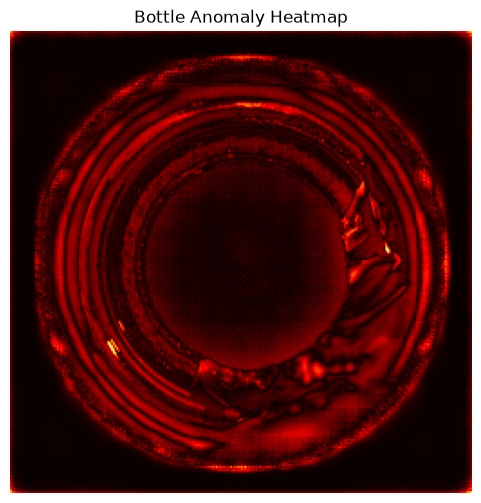

In [14]:
# --------------------------------------------------
# Visualize anomaly heatmap
# --------------------------------------------------

heatmap = (
    anomaly_map
    .squeeze(0)
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(6, 6))

plt.imshow(
    heatmap,
    cmap="hot"
)

plt.title("Bottle Anomaly Heatmap")
plt.axis("off")
plt.savefig("plot2.png", bbox_inches='tight', dpi=300)
plt.show()

In [17]:
import os
import torch
from PIL import Image
from src.data.preprocessing import get_train_transform
from src.detection.heatmap import compute_anomaly_map
from src.evaluation.metrics import compute_max_anomaly_score, compute_image_level_auroc

transform = get_train_transform()
test_root = "X:/VScode/Artificial_intelligence_n_Machine_learning/VisionInspect/dataset/mvtec_anomaly_detection/bottle/test"

scores = []
labels = []  # 0 = good, 1 = defective

model.eval()
with torch.no_grad():
    for subfolder in os.listdir(test_root):
        subfolder_path = os.path.join(test_root, subfolder)
        label = 0 if subfolder == "good" else 1

        for filename in os.listdir(subfolder_path):
            img_path = os.path.join(subfolder_path, filename)
            image = Image.open(img_path).convert("RGB")
            image_tensor = transform(image).unsqueeze(0).to(device)

            reconstructed = model(image_tensor)
            anomaly_map = compute_anomaly_map(image_tensor, reconstructed)

            score = compute_max_anomaly_score(anomaly_map.cpu().numpy())
            scores.append(score)
            labels.append(label)

auroc = compute_image_level_auroc(scores, labels)
print(f"Total test images evaluated: {len(scores)}")
print(f"Good images: {labels.count(0)}, Defective images: {labels.count(1)}")
print(f"Image-level AUROC: {auroc:.4f}")

Total test images evaluated: 83
Good images: 20, Defective images: 63
Image-level AUROC: 0.8325


In [20]:
from src.evaluation.metrics import find_best_threshold

best_threshold, tpr, fpr = find_best_threshold(scores, labels)

print(f"Best threshold: {best_threshold:.6f}")
print(f"True positive rate (defects correctly caught): {tpr:.4f}")
print(f"False positive rate (good wrongly flagged): {fpr:.4f}")

Best threshold: 0.606901
True positive rate (defects correctly caught): 0.6667
False positive rate (good wrongly flagged): 0.0500


In [19]:
import importlib
import src.evaluation.metrics as metrics

importlib.reload(metrics)

print("metrics.py reloaded")
print("find_best_threshold exists:", hasattr(metrics, "find_best_threshold"))

metrics.py reloaded
find_best_threshold exists: True


In [21]:
subfolder_names = []

scores = []
labels = []

model.eval()
with torch.no_grad():
    for subfolder in os.listdir(test_root):
        subfolder_path = os.path.join(test_root, subfolder)
        label = 0 if subfolder == "good" else 1

        for filename in os.listdir(subfolder_path):
            img_path = os.path.join(subfolder_path, filename)
            image = Image.open(img_path).convert("RGB")
            image_tensor = transform(image).unsqueeze(0).to(device)

            reconstructed = model(image_tensor)
            anomaly_map = compute_anomaly_map(image_tensor, reconstructed)

            score = compute_max_anomaly_score(anomaly_map.cpu().numpy())
            scores.append(score)
            labels.append(label)
            subfolder_names.append(subfolder)

# Now break down accuracy per defect type using our threshold
print(f"Threshold used: {best_threshold:.6f}\n")

for defect_type in set(subfolder_names):
    if defect_type == "good":
        continue

    type_scores = [s for s, name in zip(scores, subfolder_names) if name == defect_type]
    caught = sum(1 for s in type_scores if s > best_threshold)
    total = len(type_scores)

    print(f"{defect_type}: caught {caught}/{total} ({caught/total*100:.1f}%)")

Threshold used: 0.606901

broken_small: caught 22/22 (100.0%)
broken_large: caught 11/20 (55.0%)
contamination: caught 8/21 (38.1%)


In [25]:
# ============================================================
# Top-1% Anomaly Score Evaluation
# ============================================================

import os
import torch
from PIL import Image

# ------------------------------------------------------------
# Use the reloaded metrics module
# ------------------------------------------------------------

compute_topk_anomaly_score = metrics.compute_topk_anomaly_score
compute_image_level_auroc = metrics.compute_image_level_auroc
find_best_threshold = metrics.find_best_threshold

# ------------------------------------------------------------
# Test dataset
# ------------------------------------------------------------

test_root = (
    PROJECT_ROOT
    / "dataset"
    / "mvtec_anomaly_detection"
    / "bottle"
    / "test"
)

print("Test dataset:", test_root)

# ------------------------------------------------------------
# Result lists
# ------------------------------------------------------------

scores_topk = []
labels_topk = []
subfolder_names_topk = []

# ------------------------------------------------------------
# Evaluate all test images
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    for subfolder in sorted(os.listdir(test_root)):

        subfolder_path = os.path.join(
            test_root,
            subfolder
        )

        # Ignore files; only process folders
        if not os.path.isdir(subfolder_path):
            continue

        # good = 0
        # broken/contamination = 1
        label = 0 if subfolder == "good" else 1

        for filename in sorted(os.listdir(subfolder_path)):

            # Only process image files
            if not filename.lower().endswith(
                (".png", ".jpg", ".jpeg")
            ):
                continue

            img_path = os.path.join(
                subfolder_path,
                filename
            )

            # ------------------------------------------------
            # Load image
            # ------------------------------------------------

            image = Image.open(
                img_path
            ).convert("RGB")

            # ------------------------------------------------
            # Preprocess
            # ------------------------------------------------

            image_tensor = (
                transform(image)
                .unsqueeze(0)
                .to(device)
            )

            # ------------------------------------------------
            # Reconstruct image
            # ------------------------------------------------

            reconstructed = model(
                image_tensor
            )

            # ------------------------------------------------
            # Create anomaly map
            # ------------------------------------------------

            anomaly_map = compute_anomaly_map(
                image_tensor,
                reconstructed
            )

            # anomaly_map shape:
            # [1, 256, 256]
            #
            # Remove batch dimension:
            # [256, 256]

            anomaly_map_numpy = (
                anomaly_map
                .squeeze(0)
                .detach()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # Top-1% anomaly score
            # ------------------------------------------------

            score = compute_topk_anomaly_score(
                anomaly_map_numpy,
                k_percent=1.0
            )

            # ------------------------------------------------
            # Save result
            # ------------------------------------------------

            scores_topk.append(score)
            labels_topk.append(label)
            subfolder_names_topk.append(subfolder)

# ------------------------------------------------------------
# Calculate AUROC
# ------------------------------------------------------------

auroc_topk = compute_image_level_auroc(
    scores_topk,
    labels_topk
)

# ------------------------------------------------------------
# Find best threshold
# ------------------------------------------------------------

best_threshold_topk, tpr_topk, fpr_topk = (
    find_best_threshold(
        scores_topk,
        labels_topk
    )
)

# ------------------------------------------------------------
# Print overall results
# ------------------------------------------------------------

print()
print("=" * 60)
print("TOP-1% ANOMALY SCORE RESULTS")
print("=" * 60)

print(
    f"Total test images: {len(scores_topk)}"
)

print(
    f"Normal images: {labels_topk.count(0)}"
)

print(
    f"Defective images: {labels_topk.count(1)}"
)

print(
    f"AUROC: {auroc_topk:.4f}"
)

print(
    f"Best threshold: {best_threshold_topk:.6f}"
)

print(
    f"True positive rate (TPR): {tpr_topk:.4f}"
)

print(
    f"False positive rate (FPR): {fpr_topk:.4f}"
)

# ------------------------------------------------------------
# Results for each defect type
# ------------------------------------------------------------

print()
print("=" * 60)
print("RESULTS BY DEFECT TYPE")
print("=" * 60)

for defect_type in sorted(
    set(subfolder_names_topk)
):

    if defect_type == "good":
        continue

    type_scores = [
        score
        for score, name in zip(
            scores_topk,
            subfolder_names_topk
        )
        if name == defect_type
    ]

    caught = sum(
        score > best_threshold_topk
        for score in type_scores
    )

    total = len(type_scores)

    percentage = (
        caught / total * 100
        if total > 0
        else 0.0
    )

    print(
        f"{defect_type}: "
        f"caught {caught}/{total} "
        f"({percentage:.1f}%)"
    )

Test dataset: X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\dataset\mvtec_anomaly_detection\bottle\test

TOP-1% ANOMALY SCORE RESULTS
Total test images: 83
Normal images: 20
Defective images: 63
AUROC: 0.7333
Best threshold: 0.277022
True positive rate (TPR): 0.5397
False positive rate (FPR): 0.0000

RESULTS BY DEFECT TYPE
broken_large: caught 11/20 (55.0%)
broken_small: caught 15/22 (68.2%)
contamination: caught 7/21 (33.3%)


In [26]:
# ============================================================
# Experiment: Find the best Top-K anomaly percentage
# ============================================================

import numpy as np

# Use the already loaded metrics module
compute_max_anomaly_score = metrics.compute_max_anomaly_score
compute_topk_anomaly_score = metrics.compute_topk_anomaly_score
compute_image_level_auroc = metrics.compute_image_level_auroc

# ------------------------------------------------------------
# Percentages to test
# ------------------------------------------------------------

topk_percentages = [
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    1.00
]

results = []

# ------------------------------------------------------------
# Test each percentage
# ------------------------------------------------------------

for k_percent in topk_percentages:

    scores = []

    model.eval()

    with torch.no_grad():

        for subfolder in sorted(os.listdir(test_root)):

            subfolder_path = os.path.join(
                test_root,
                subfolder
            )

            if not os.path.isdir(subfolder_path):
                continue

            for filename in sorted(
                os.listdir(subfolder_path)
            ):

                if not filename.lower().endswith(
                    (".png", ".jpg", ".jpeg")
                ):
                    continue

                img_path = os.path.join(
                    subfolder_path,
                    filename
                )

                image = Image.open(
                    img_path
                ).convert("RGB")

                image_tensor = (
                    transform(image)
                    .unsqueeze(0)
                    .to(device)
                )

                reconstructed = model(
                    image_tensor
                )

                anomaly_map = compute_anomaly_map(
                    image_tensor,
                    reconstructed
                )

                anomaly_map_numpy = (
                    anomaly_map
                    .squeeze(0)
                    .detach()
                    .cpu()
                    .numpy()
                )

                # ------------------------------------------------
                # MAX is our baseline
                # ------------------------------------------------

                if k_percent == 0.01:

                    score = compute_max_anomaly_score(
                        anomaly_map_numpy
                    )

                else:

                    score = compute_topk_anomaly_score(
                        anomaly_map_numpy,
                        k_percent=k_percent
                    )

                scores.append(score)

    # --------------------------------------------------------
    # AUROC
    # --------------------------------------------------------

    auroc = compute_image_level_auroc(
        scores,
        labels_topk
    )

    results.append(
        (k_percent, auroc)
    )

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print()
print("=" * 50)
print("TOP-K EXPERIMENT")
print("=" * 50)

for k_percent, auroc in results:

    if k_percent == 0.01:
        name = "MAX"
    else:
        name = f"TOP {k_percent}%"

    print(
        f"{name:<12} AUROC: {auroc:.4f}"
    )

# ------------------------------------------------------------
# Best result
# ------------------------------------------------------------

best_k, best_auroc = max(
    results,
    key=lambda x: x[1]
)

print()
print("=" * 50)
print(
    f"BEST: TOP {best_k}%"
)
print(
    f"BEST AUROC: {best_auroc:.4f}"
)
print("=" * 50)


TOP-K EXPERIMENT
MAX          AUROC: 0.8325
TOP 0.05%    AUROC: 0.7317
TOP 0.1%     AUROC: 0.7476
TOP 0.25%    AUROC: 0.7762
TOP 0.5%     AUROC: 0.7754
TOP 1.0%     AUROC: 0.7333

BEST: TOP 0.01%
BEST AUROC: 0.8325


In [27]:
# ============================================================
# Per-defect-type evaluation using MAX anomaly score
# ============================================================

import os
import torch
from PIL import Image

# ------------------------------------------------------------
# Test dataset
# ------------------------------------------------------------

test_root = (
    PROJECT_ROOT
    / "dataset"
    / "mvtec_anomaly_detection"
    / "bottle"
    / "test"
)

# ------------------------------------------------------------
# Collect MAX anomaly scores
# ------------------------------------------------------------

scores_max = []
labels_max = []
categories_max = []

model.eval()

with torch.no_grad():

    for category in sorted(os.listdir(test_root)):

        category_path = os.path.join(
            test_root,
            category
        )

        if not os.path.isdir(category_path):
            continue

        label = 0 if category == "good" else 1

        for filename in sorted(os.listdir(category_path)):

            if not filename.lower().endswith(
                (".png", ".jpg", ".jpeg")
            ):
                continue

            image_path = os.path.join(
                category_path,
                filename
            )

            # Load image
            image = Image.open(
                image_path
            ).convert("RGB")

            # Preprocess
            image_tensor = (
                transform(image)
                .unsqueeze(0)
                .to(device)
            )

            # Reconstruction
            reconstructed = model(
                image_tensor
            )

            # Anomaly map
            anomaly_map = compute_anomaly_map(
                image_tensor,
                reconstructed
            )

            # Remove batch dimension
            anomaly_map_numpy = (
                anomaly_map
                .squeeze(0)
                .detach()
                .cpu()
                .numpy()
            )

            # MAX anomaly score
            score = compute_max_anomaly_score(
                anomaly_map_numpy
            )

            scores_max.append(score)
            labels_max.append(label)
            categories_max.append(category)

# ------------------------------------------------------------
# Overall AUROC
# ------------------------------------------------------------

auroc_max = compute_image_level_auroc(
    scores_max,
    labels_max
)

# ------------------------------------------------------------
# Best threshold
# ------------------------------------------------------------

best_threshold_max, tpr_max, fpr_max = (
    find_best_threshold(
        scores_max,
        labels_max
    )
)

print()
print("=" * 60)
print("MAX ANOMALY SCORE — OVERALL")
print("=" * 60)

print(f"AUROC: {auroc_max:.4f}")
print(f"Best threshold: {best_threshold_max:.6f}")
print(f"TPR: {tpr_max:.4f}")
print(f"FPR: {fpr_max:.4f}")

# ------------------------------------------------------------
# Per-defect-type results
# ------------------------------------------------------------

print()
print("=" * 60)
print("MAX SCORE — RESULTS BY CATEGORY")
print("=" * 60)

for category in sorted(set(categories_max)):

    category_scores = [
        score
        for score, name
        in zip(
            scores_max,
            categories_max
        )
        if name == category
    ]

    if category == "good":

        # How many normal images would be incorrectly flagged?
        false_positives = sum(
            score > best_threshold_max
            for score in category_scores
        )

        print(
            f"good: "
            f"{false_positives}/{len(category_scores)} "
            f"false positives "
            f"({false_positives / len(category_scores) * 100:.1f}%)"
        )

    else:

        # How many defective images were detected?
        caught = sum(
            score > best_threshold_max
            for score in category_scores
        )

        total = len(category_scores)

        detection_rate = (
            caught / total * 100
            if total > 0
            else 0
        )

        print(
            f"{category}: "
            f"{caught}/{total} detected "
            f"({detection_rate:.1f}%)"
        )


MAX ANOMALY SCORE — OVERALL
AUROC: 0.8325
Best threshold: 0.606901
TPR: 0.6667
FPR: 0.0500

MAX SCORE — RESULTS BY CATEGORY
broken_large: 11/20 detected (55.0%)
broken_small: 22/22 detected (100.0%)
contamination: 8/21 detected (38.1%)
good: 1/20 false positives (5.0%)


In [35]:
# ============================================================
# Visual inspection of anomaly maps
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

def inspect_defect(category, filename="000.png"):
    """
    Show:
    1. Original image
    2. Reconstruction
    3. Anomaly heatmap
    """

    image_path = (
        PROJECT_ROOT
        / "dataset"
        / "mvtec_anomaly_detection"
        / "bottle"
        / "test"
        / category
        / filename
    )

    image = Image.open(image_path).convert("RGB")

    image_tensor = (
        transform(image)
        .unsqueeze(0)
        .to(device)
    )

    model.eval()

    with torch.no_grad():
        reconstructed = model(image_tensor)

    anomaly_map = compute_anomaly_map(
        image_tensor,
        reconstructed
    )

    # Original
    original = (
        image_tensor
        .squeeze(0)
        .detach()
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    # Reconstruction
    reconstruction = (
        reconstructed
        .squeeze(0)
        .detach()
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    # Heatmap
    heatmap = (
        anomaly_map
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
    )

    # MAX score
    max_score = compute_max_anomaly_score(heatmap)

    print("Category:", category)
    print("Image:", filename)
    print(f"MAX anomaly score: {max_score:.6f}")
    print(
        f"Threshold: {best_threshold_max:.6f}"
    )

    if max_score > best_threshold_max:
        print("Prediction: DEFECTIVE")
    else:
        print("Prediction: GOOD")

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(reconstruction)
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(heatmap, cmap="hot")
    plt.title("Anomaly Heatmap")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Category: broken_large
Image: 000.png
MAX anomaly score: 0.535785
Threshold: 0.606901
Prediction: GOOD


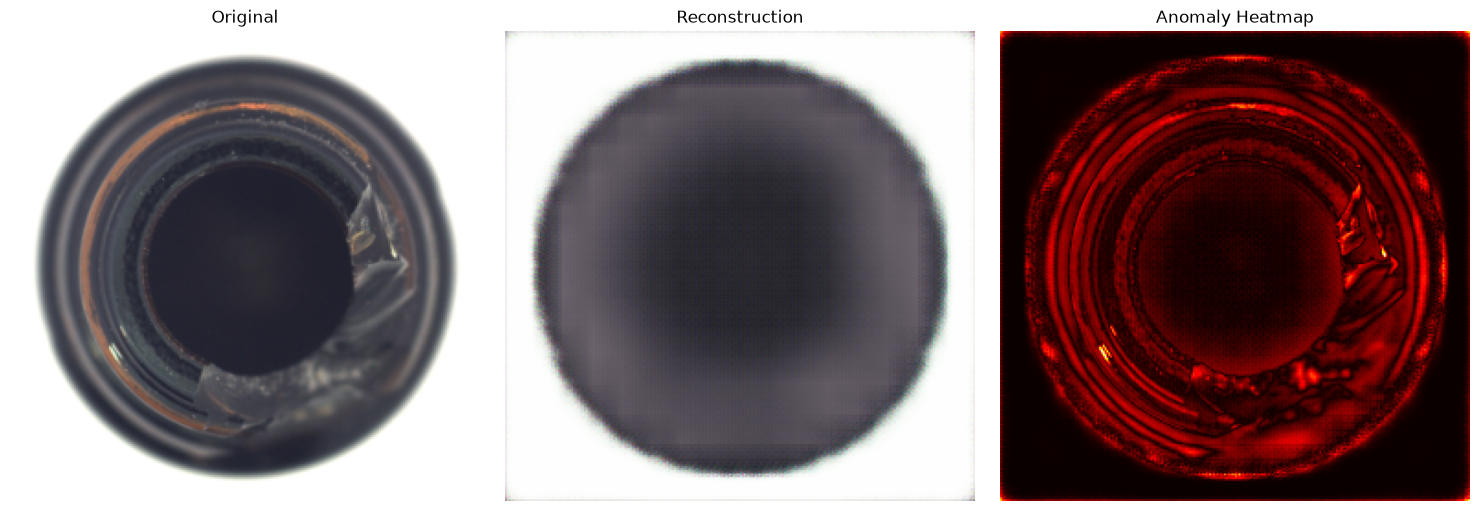

In [36]:
inspect_defect("broken_large")

Category: contamination
Image: 000.png
MAX anomaly score: 0.532917
Threshold: 0.606901
Prediction: GOOD


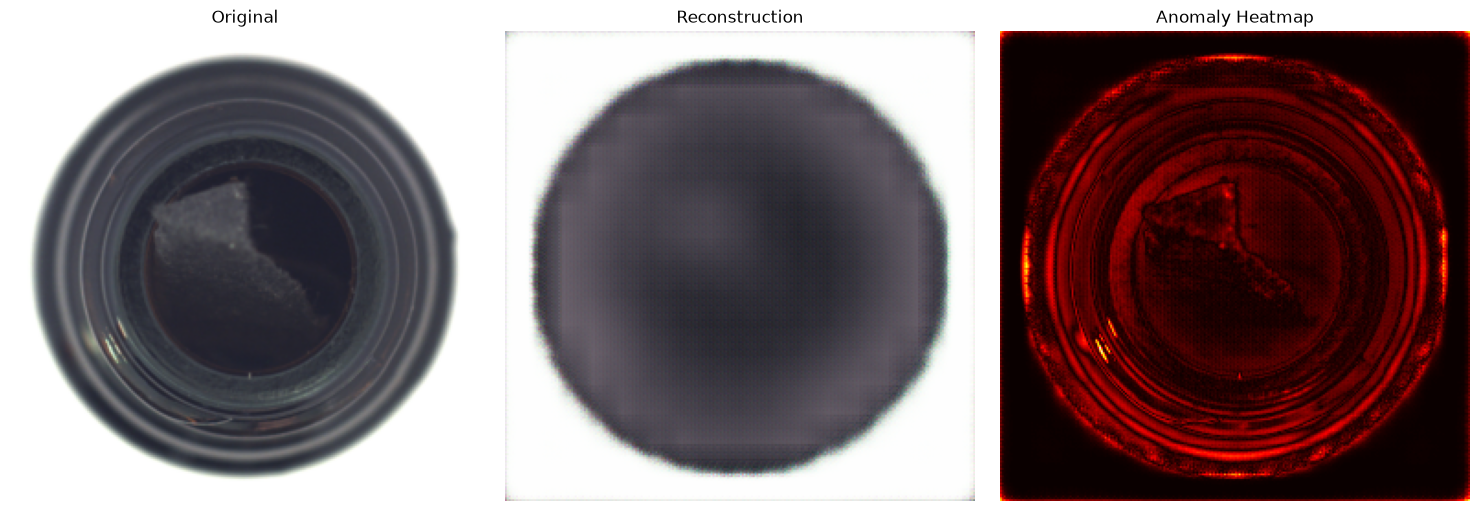

In [38]:
inspect_defect("contamination")

Category: good
Image: 000.png
MAX anomaly score: 0.532821
Threshold: 0.606901
Prediction: GOOD


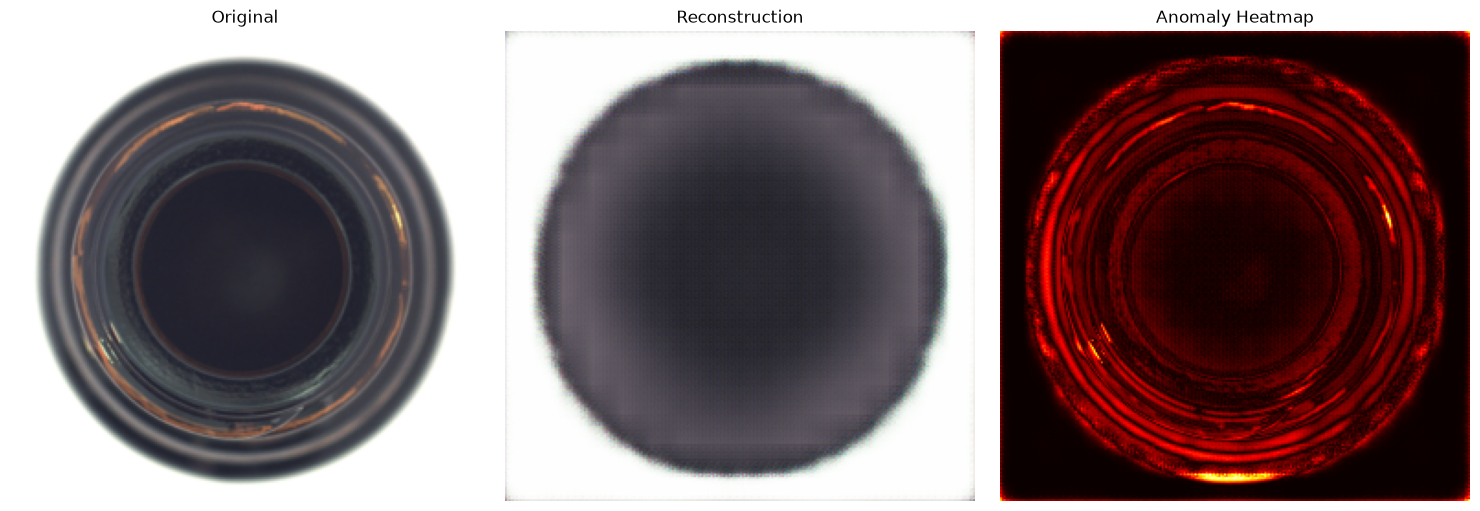

In [39]:
inspect_defect("good")

In [40]:
# ============================================================
# Experiment: Interior ROI MAX anomaly score
# ============================================================

import os
import numpy as np
import torch
from PIL import Image

# ------------------------------------------------------------
# ROI definition
# ------------------------------------------------------------
# Our images are 256 x 256 after preprocessing.
#
# We ignore the outer bottle/rim area and evaluate only
# the central interior region.
#
# This is an EXPERIMENT only.
# We are NOT changing the actual detector yet.
# ------------------------------------------------------------

IMAGE_SIZE = 256

# Central square ROI
ROI_TOP = 60
ROI_BOTTOM = 196
ROI_LEFT = 60
ROI_RIGHT = 196

print("ROI:")
print(
    f"Rows: {ROI_TOP}:{ROI_BOTTOM}"
)
print(
    f"Columns: {ROI_LEFT}:{ROI_RIGHT}"
)

# ------------------------------------------------------------
# Test dataset
# ------------------------------------------------------------

test_root = (
    PROJECT_ROOT
    / "dataset"
    / "mvtec_anomaly_detection"
    / "bottle"
    / "test"
)

# ------------------------------------------------------------
# Collect ROI scores
# ------------------------------------------------------------

scores_roi = []
labels_roi = []
categories_roi = []

model.eval()

with torch.no_grad():

    for category in sorted(os.listdir(test_root)):

        category_path = os.path.join(
            test_root,
            category
        )

        if not os.path.isdir(category_path):
            continue

        # good = 0
        # defect = 1
        label = 0 if category == "good" else 1

        for filename in sorted(
            os.listdir(category_path)
        ):

            if not filename.lower().endswith(
                (".png", ".jpg", ".jpeg")
            ):
                continue

            image_path = os.path.join(
                category_path,
                filename
            )

            # ------------------------------------------------
            # Load image
            # ------------------------------------------------

            image = Image.open(
                image_path
            ).convert("RGB")

            # ------------------------------------------------
            # Preprocess
            # ------------------------------------------------

            image_tensor = (
                transform(image)
                .unsqueeze(0)
                .to(device)
            )

            # ------------------------------------------------
            # Reconstruction
            # ------------------------------------------------

            reconstructed = model(
                image_tensor
            )

            # ------------------------------------------------
            # Anomaly map
            # ------------------------------------------------

            anomaly_map = compute_anomaly_map(
                image_tensor,
                reconstructed
            )

            anomaly_map_numpy = (
                anomaly_map
                .squeeze(0)
                .detach()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # Crop to interior ROI
            # ------------------------------------------------

            roi = anomaly_map_numpy[
                ROI_TOP:ROI_BOTTOM,
                ROI_LEFT:ROI_RIGHT
            ]

            # ------------------------------------------------
            # MAX anomaly score inside ROI
            # ------------------------------------------------

            score = float(
                np.max(roi)
            )

            scores_roi.append(score)
            labels_roi.append(label)
            categories_roi.append(category)

# ------------------------------------------------------------
# Calculate AUROC
# ------------------------------------------------------------

auroc_roi = compute_image_level_auroc(
    scores_roi,
    labels_roi
)

# ------------------------------------------------------------
# Find best threshold
# ------------------------------------------------------------

best_threshold_roi, tpr_roi, fpr_roi = (
    find_best_threshold(
        scores_roi,
        labels_roi
    )
)

# ------------------------------------------------------------
# Overall results
# ------------------------------------------------------------

print()
print("=" * 60)
print("INTERIOR ROI MAX RESULTS")
print("=" * 60)

print(
    f"AUROC: {auroc_roi:.4f}"
)

print(
    f"Best threshold: {best_threshold_roi:.6f}"
)

print(
    f"TPR: {tpr_roi:.4f}"
)

print(
    f"FPR: {fpr_roi:.4f}"
)

# ------------------------------------------------------------
# Results by defect category
# ------------------------------------------------------------

print()
print("=" * 60)
print("ROI RESULTS BY CATEGORY")
print("=" * 60)

for category in sorted(
    set(categories_roi)
):

    category_scores = [
        score
        for score, name in zip(
            scores_roi,
            categories_roi
        )
        if name == category
    ]

    if category == "good":

        false_positives = sum(
            score > best_threshold_roi
            for score in category_scores
        )

        percentage = (
            false_positives
            / len(category_scores)
            * 100
        )

        print(
            f"good: "
            f"{false_positives}/{len(category_scores)} "
            f"false positives "
            f"({percentage:.1f}%)"
        )

    else:

        caught = sum(
            score > best_threshold_roi
            for score in category_scores
        )

        total = len(category_scores)

        percentage = (
            caught / total * 100
            if total > 0
            else 0
        )

        print(
            f"{category}: "
            f"{caught}/{total} detected "
            f"({percentage:.1f}%)"
        )

ROI:
Rows: 60:196
Columns: 60:196

INTERIOR ROI MAX RESULTS
AUROC: 0.8286
Best threshold: 0.492256
TPR: 0.7143
FPR: 0.0000

ROI RESULTS BY CATEGORY
broken_large: 16/20 detected (80.0%)
broken_small: 22/22 detected (100.0%)
contamination: 6/21 detected (28.6%)
good: 0/20 false positives (0.0%)


In [41]:
# ============================================================
# Experiment: Percentile-based anomaly scores
# ============================================================

import os
import numpy as np
import torch
from PIL import Image

# ------------------------------------------------------------
# Percentiles to test
# ------------------------------------------------------------

percentiles = [
    99.0,
    99.5,
    99.9,
    99.95,
    99.99
]

# ------------------------------------------------------------
# Test dataset
# ------------------------------------------------------------

test_root = (
    PROJECT_ROOT
    / "dataset"
    / "mvtec_anomaly_detection"
    / "bottle"
    / "test"
)

# ------------------------------------------------------------
# Store anomaly maps once
# ------------------------------------------------------------

all_anomaly_maps = []
all_labels = []
all_categories = []

model.eval()

with torch.no_grad():

    for category in sorted(os.listdir(test_root)):

        category_path = os.path.join(
            test_root,
            category
        )

        if not os.path.isdir(category_path):
            continue

        label = 0 if category == "good" else 1

        for filename in sorted(os.listdir(category_path)):

            if not filename.lower().endswith(
                (".png", ".jpg", ".jpeg")
            ):
                continue

            image_path = os.path.join(
                category_path,
                filename
            )

            # Load image
            image = Image.open(
                image_path
            ).convert("RGB")

            # Preprocess
            image_tensor = (
                transform(image)
                .unsqueeze(0)
                .to(device)
            )

            # Reconstruction
            reconstructed = model(
                image_tensor
            )

            # Anomaly map
            anomaly_map = compute_anomaly_map(
                image_tensor,
                reconstructed
            )

            anomaly_map_numpy = (
                anomaly_map
                .squeeze(0)
                .detach()
                .cpu()
                .numpy()
            )

            all_anomaly_maps.append(
                anomaly_map_numpy
            )

            all_labels.append(label)
            all_categories.append(category)

print(
    f"Collected anomaly maps: "
    f"{len(all_anomaly_maps)}"
)

# ------------------------------------------------------------
# Test every percentile
# ------------------------------------------------------------

percentile_results = []

for percentile in percentiles:

    scores_percentile = []

    for anomaly_map in all_anomaly_maps:

        score = float(
            np.percentile(
                anomaly_map,
                percentile
            )
        )

        scores_percentile.append(score)

    # AUROC
    auroc = compute_image_level_auroc(
        scores_percentile,
        all_labels
    )

    # Best threshold
    threshold, tpr, fpr = find_best_threshold(
        scores_percentile,
        all_labels
    )

    percentile_results.append(
        (
            percentile,
            auroc,
            threshold,
            tpr,
            fpr,
            scores_percentile
        )
    )

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print()
print("=" * 75)
print("PERCENTILE ANOMALY SCORE EXPERIMENT")
print("=" * 75)

for (
    percentile,
    auroc,
    threshold,
    tpr,
    fpr,
    scores
) in percentile_results:

    print(
        f"P{percentile:<6.2f} "
        f"| AUROC: {auroc:.4f} "
        f"| TPR: {tpr:.4f} "
        f"| FPR: {fpr:.4f}"
    )

# ------------------------------------------------------------
# Find best percentile by AUROC
# ------------------------------------------------------------

best_result = max(
    percentile_results,
    key=lambda x: x[1]
)

(
    best_percentile,
    best_auroc,
    best_threshold,
    best_tpr,
    best_fpr,
    best_scores
) = best_result

print()
print("=" * 75)
print("BEST PERCENTILE")
print("=" * 75)

print(
    f"Best percentile: P{best_percentile}"
)

print(
    f"Best AUROC: {best_auroc:.4f}"
)

print(
    f"Best threshold: {best_threshold:.6f}"
)

print(
    f"TPR: {best_tpr:.4f}"
)

print(
    f"FPR: {best_fpr:.4f}"
)

# ------------------------------------------------------------
# Per-category performance for best percentile
# ------------------------------------------------------------

print()
print("=" * 75)
print("BEST PERCENTILE — RESULTS BY CATEGORY")
print("=" * 75)

for category in sorted(
    set(all_categories)
):

    category_scores = [
        score
        for score, name
        in zip(
            best_scores,
            all_categories
        )
        if name == category
    ]

    if category == "good":

        false_positives = sum(
            score > best_threshold
            for score in category_scores
        )

        percentage = (
            false_positives
            / len(category_scores)
            * 100
        )

        print(
            f"{category}: "
            f"{false_positives}/{len(category_scores)} "
            f"false positives "
            f"({percentage:.1f}%)"
        )

    else:

        caught = sum(
            score > best_threshold
            for score in category_scores
        )

        total = len(category_scores)

        percentage = (
            caught / total * 100
            if total > 0
            else 0
        )

        print(
            f"{category}: "
            f"{caught}/{total} detected "
            f"({percentage:.1f}%)"
        )

Collected anomaly maps: 83

PERCENTILE ANOMALY SCORE EXPERIMENT
P99.00  | AUROC: 0.4730 | TPR: 0.1905 | FPR: 0.0500
P99.50  | AUROC: 0.6730 | TPR: 0.4762 | FPR: 0.0500
P99.90  | AUROC: 0.7683 | TPR: 0.5873 | FPR: 0.0500
P99.95  | AUROC: 0.7294 | TPR: 0.5873 | FPR: 0.0500
P99.99  | AUROC: 0.7167 | TPR: 0.6032 | FPR: 0.1500

BEST PERCENTILE
Best percentile: P99.9
Best AUROC: 0.7683
Best threshold: 0.390984
TPR: 0.5873
FPR: 0.0500

BEST PERCENTILE — RESULTS BY CATEGORY
broken_large: 12/20 detected (60.0%)
broken_small: 16/22 detected (72.7%)
contamination: 8/21 detected (38.1%)
good: 1/20 false positives (5.0%)


In [48]:
# ============================================================
# Pixel-level evaluation against MVTec ground-truth masks
# ============================================================

import os
import numpy as np
import torch
from PIL import Image

pixel_tp = 0
pixel_fp = 0
pixel_fn = 0

evaluated_images = 0

model.eval()

with torch.no_grad():

    for defect_type in [
        "broken_large",
        "broken_small",
        "contamination"
    ]:

        test_dir = test_root / defect_type
        mask_dir = ground_truth_root / defect_type

        for filename in sorted(os.listdir(test_dir)):

            if not filename.lower().endswith(".png"):
                continue

            # Example:
            # test image  = 000.png
            # mask        = 000_mask.png

            image_path = test_dir / filename

            image_number = Path(filename).stem

            mask_filename = (
                f"{image_number}_mask.png"
            )

            mask_path = (
                mask_dir / mask_filename
            )

            # Make sure the mask exists
            if not mask_path.exists():
                print(
                    f"Missing mask: {mask_path}"
                )
                continue

            # ------------------------------------------------
            # Load image
            # ------------------------------------------------

            image = Image.open(
                image_path
            ).convert("RGB")

            # ------------------------------------------------
            # Preprocess
            # ------------------------------------------------

            image_tensor = (
                transform(image)
                .unsqueeze(0)
                .to(device)
            )

            # ------------------------------------------------
            # Reconstruction
            # ------------------------------------------------

            reconstructed = model(
                image_tensor
            )

            # ------------------------------------------------
            # Anomaly map
            # ------------------------------------------------

            anomaly_map = compute_anomaly_map(
                image_tensor,
                reconstructed
            )

            anomaly_map = (
                anomaly_map
                .squeeze(0)
                .detach()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # Load ground-truth mask
            # ------------------------------------------------

            ground_truth = Image.open(
                mask_path
            ).convert("L")

            ground_truth = ground_truth.resize(
                (256, 256)
            )

            ground_truth = np.array(
                ground_truth
            )

            ground_truth_binary = (
                ground_truth > 0
            )

            # ------------------------------------------------
            # Create predicted anomaly mask
            # ------------------------------------------------

            prediction_binary = (
                anomaly_map > pixel_threshold
            )

            # ------------------------------------------------
            # Pixel TP / FP / FN
            # ------------------------------------------------

            tp = np.logical_and(
                prediction_binary,
                ground_truth_binary
            ).sum()

            fp = np.logical_and(
                prediction_binary,
                ~ground_truth_binary
            ).sum()

            fn = np.logical_and(
                ~prediction_binary,
                ground_truth_binary
            ).sum()

            pixel_tp += int(tp)
            pixel_fp += int(fp)
            pixel_fn += int(fn)

            evaluated_images += 1


# ============================================================
# Calculate metrics
# ============================================================

pixel_precision = (
    pixel_tp / (pixel_tp + pixel_fp)
    if (pixel_tp + pixel_fp) > 0
    else 0.0
)

pixel_recall = (
    pixel_tp / (pixel_tp + pixel_fn)
    if (pixel_tp + pixel_fn) > 0
    else 0.0
)

pixel_iou = (
    pixel_tp /
    (pixel_tp + pixel_fp + pixel_fn)
    if (pixel_tp + pixel_fp + pixel_fn) > 0
    else 0.0
)


# ============================================================
# Print results
# ============================================================

print()
print("=" * 60)
print("PIXEL-LEVEL EVALUATION")
print("=" * 60)

print(
    f"Images evaluated: {evaluated_images}"
)

print(
    f"Pixel precision: {pixel_precision:.4f}"
)

print(
    f"Pixel recall:    {pixel_recall:.4f}"
)

print(
    f"Pixel IoU:       {pixel_iou:.4f}"
)

print()
print("Raw counts:")
print(f"TP: {pixel_tp}")
print(f"FP: {pixel_fp}")
print(f"FN: {pixel_fn}")


PIXEL-LEVEL EVALUATION
Images evaluated: 63
Pixel precision: 0.9764
Pixel recall:    0.0016
Pixel IoU:       0.0016

Raw counts:
TP: 537
FP: 13
FN: 329659


In [43]:
from pathlib import Path

ground_truth_root = (
    PROJECT_ROOT
    / "dataset"
    / "mvtec_anomaly_detection"
    / "bottle"
    / "ground_truth"
)

test_root = (
    PROJECT_ROOT
    / "dataset"
    / "mvtec_anomaly_detection"
    / "bottle"
    / "test"
)

pixel_threshold = best_threshold_max

print("Ground truth root:")
print(ground_truth_root)

print()
print("Test root:")
print(test_root)

print()
print(f"Pixel threshold: {pixel_threshold:.6f}")

Ground truth root:
X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\dataset\mvtec_anomaly_detection\bottle\ground_truth

Test root:
X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\dataset\mvtec_anomaly_detection\bottle\test

Pixel threshold: 0.606901
